<a href="https://colab.research.google.com/github/flor-g/flor-g/blob/main/neural_network_playground.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


# Parameters
IMAGE_SIZE = 100  # 100x100 images
NUM_PIXELS = IMAGE_SIZE * IMAGE_SIZE
NUM_SAMPLES = 80
HIDDEN_UNITS = 512
EPOCHS = 50
BATCH_SIZE = 8
LEARNING_RATE = 1e-3
MASK_PIXELS = 80  # Number of pixels revealed in each input

In [10]:
def generate_dataset(num_samples: int):
    """Generate datasets from a fixed sine-wave image.

    A single sine curve with a constant amplitude is drawn once. For each
    sample, 80 pixels from this curve image are revealed while the rest are
    set to ``0`` in the input. The full image is used as the training target.
    """

    # Build the fixed sine-wave image
    base_image = np.zeros((IMAGE_SIZE, IMAGE_SIZE), dtype=np.float32)
    x_vals = np.linspace(0.0, np.pi, IMAGE_SIZE)
    amplitude = IMAGE_SIZE * 0.4
    center = IMAGE_SIZE / 2.0
    for x_pixel, x in enumerate(x_vals):
        y = amplitude * np.sin(x)
        y_pos = center - y
        lower = int(np.floor(y_pos))
        upper = int(np.ceil(y_pos))
        if 0 <= lower < IMAGE_SIZE:
            base_image[lower, x_pixel] = 1.0
        if 0 <= upper < IMAGE_SIZE:
            base_image[upper, x_pixel] = 1.0

    flat_image = base_image.reshape(NUM_PIXELS)

    # Generate inputs by revealing a random subset of pixels
    inputs = np.zeros((num_samples, NUM_PIXELS), dtype=np.float32)
    for i in range(num_samples):
        mask = np.zeros(NUM_PIXELS, dtype=np.float32)
        indices = np.random.choice(NUM_PIXELS, MASK_PIXELS, replace=False)
        mask[indices] = 1.0
        inputs[i] = flat_image * mask

    targets = np.repeat(flat_image[None, :], num_samples, axis=0)
    return inputs, targets


class TwoLayerNet(nn.Module):
    """Simple two-layer fully connected neural network."""

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(NUM_PIXELS, HIDDEN_UNITS)
        self.relu = nn.Tanh()
        self.fc2 = nn.Linear(HIDDEN_UNITS, NUM_PIXELS)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x


def train(model, dataloader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for batch_inputs, batch_targets in dataloader:
        optimizer.zero_grad()
        outputs = model(batch_inputs)
        loss = criterion(outputs, batch_targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch_inputs.size(0)
    return total_loss / len(dataloader.dataset)


def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for batch_inputs, batch_targets in dataloader:
            outputs = model(batch_inputs)
            loss = criterion(outputs, batch_targets)
            total_loss += loss.item() * batch_inputs.size(0)
    return total_loss / len(dataloader.dataset)


def visualize_results(model, input_image, target_image):
    model.eval()
    with torch.no_grad():
        output = model(torch.from_numpy(input_image).unsqueeze(0)).squeeze(0).numpy()
    output_image = (output > 0.5).astype(np.float32)  # Threshold for binary output

    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    axes[0].imshow(target_image.reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
    axes[0].set_title('Original')
    axes[0].axis('off')

    axes[1].imshow(input_image.reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
    axes[1].set_title('Input (Masked)')
    axes[1].axis('off')

    axes[2].imshow(output_image.reshape(IMAGE_SIZE, IMAGE_SIZE), cmap='gray')
    axes[2].set_title('Predicted')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()



Epoch 1/50 - Train Loss: 0.6869 - Val Loss: 0.6746
Epoch 2/50 - Train Loss: 0.6541 - Val Loss: 0.6273
Epoch 3/50 - Train Loss: 0.5792 - Val Loss: 0.5393
Epoch 4/50 - Train Loss: 0.4603 - Val Loss: 0.4170
Epoch 5/50 - Train Loss: 0.3174 - Val Loss: 0.2859
Epoch 6/50 - Train Loss: 0.1935 - Val Loss: 0.1803
Epoch 7/50 - Train Loss: 0.1106 - Val Loss: 0.1115
Epoch 8/50 - Train Loss: 0.0654 - Val Loss: 0.0722
Epoch 9/50 - Train Loss: 0.0413 - Val Loss: 0.0502
Epoch 10/50 - Train Loss: 0.0286 - Val Loss: 0.0373
Epoch 11/50 - Train Loss: 0.0213 - Val Loss: 0.0293
Epoch 12/50 - Train Loss: 0.0167 - Val Loss: 0.0241
Epoch 13/50 - Train Loss: 0.0137 - Val Loss: 0.0203
Epoch 14/50 - Train Loss: 0.0116 - Val Loss: 0.0175
Epoch 15/50 - Train Loss: 0.0099 - Val Loss: 0.0154
Epoch 16/50 - Train Loss: 0.0087 - Val Loss: 0.0136
Epoch 17/50 - Train Loss: 0.0077 - Val Loss: 0.0122
Epoch 18/50 - Train Loss: 0.0069 - Val Loss: 0.0110
Epoch 19/50 - Train Loss: 0.0062 - Val Loss: 0.0100
Epoch 20/50 - Train L

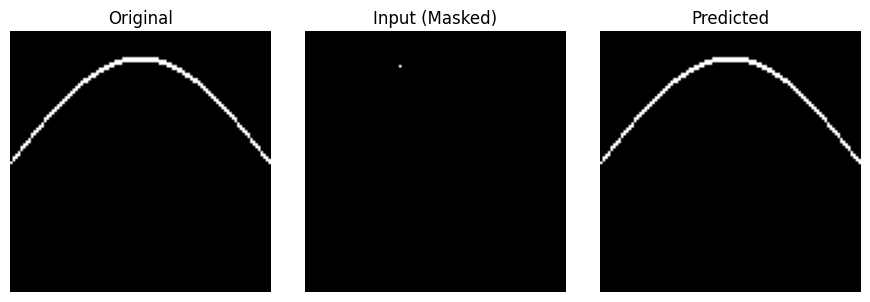

In [11]:
if __name__ == "__main__":
    # Generate sine-wave dataset.
    inputs, targets = generate_dataset(NUM_SAMPLES)

    # Convert to PyTorch tensors
    inputs_tensor = torch.from_numpy(inputs)
    targets_tensor = torch.from_numpy(targets)

    # Split into training and validation sets
    train_size = int(0.8 * NUM_SAMPLES)
    val_size = NUM_SAMPLES - train_size
    train_dataset = TensorDataset(inputs_tensor[:train_size], targets_tensor[:train_size])
    val_dataset = TensorDataset(inputs_tensor[train_size:], targets_tensor[train_size:])

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

    # Initialize model, loss, optimizer
    model = TwoLayerNet()
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # Training loop
    for epoch in range(EPOCHS):
        train_loss = train(model, train_loader, criterion, optimizer)
        val_loss = evaluate(model, val_loader, criterion)
        print(f"Epoch {epoch+1}/{EPOCHS} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}")

    # Visualize results on a random validation sample
    idx = np.random.randint(0, val_size)
    input_img = inputs[train_size + idx]
    target_img = targets[train_size + idx]
    visualize_results(model, input_img, target_img)